In [ ]:
%load_ext autoreload
%autoreload 2
import jax
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import objax
import bayesnewton
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load 2x4 grid of geopotential values, for 30 days training and 14 days testing

In [177]:
from data_processing import load_xarray, process_xarray

z500_xarray = load_xarray('data/5.625deg/geopotential_500', 'z')

t_train_slice = slice('2017-11-01', '2017-11-30')
t_test_slice = slice('2017-12-01', '2017-12-15')
lat_slice = slice(40, 50)
lon_slice = slice(0, 20)
t_train, x, y_train = process_xarray(z500_xarray, t_train_slice, lat_slice, lon_slice)
t_test, _, y_test = process_xarray(z500_xarray, t_test_slice, lat_slice, lon_slice)
t_test += t_train[-1]

print(f'Array shapes:')
print(f't: train {t_train.shape}, test {t_test.shape}')
print(f'x: {x.shape}')
print(f'y: train {y_train.shape}, test {y_test.shape}')

latitudes = np.unique(x[:, 0])
longitudes = np.unique(x[:, 1])
print()
print(f"Latitudes: {latitudes}")
print(f"Longitudes: {longitudes}")

Array shapes:
t: train (720,), test (360,)
x: (8, 2)
y: train (720, 8), test (360, 8)

Latitudes: [42.1875 47.8125]
Longitudes: [ 0.     5.625 11.25  16.875]


In [128]:
# Normalise only using the training data
y_mean, y_std = y_train.mean(axis=0), y_train.std(axis=0)
y_train_normalised = (y_train - y_mean) / y_std

In [129]:
# Repeat x with shape (n_space, 2) n_time times to get an array of shape (n_time, n_space, 2)
# Required for the spatiotemporal GP model
x_spatiotemporal = np.repeat(x[None, ...], len(t_train), axis=0)

Initialise the kernel and the state-space GP

In [130]:
import bayesnewton
from models.state_space import SpatioTemporalKernel, StateSpaceGaussianProcess

In [131]:
# Initialise kernel hyperparameters
lengthscale_space = 10.0
lengthscale_time = 10.0
variance = 0.2

variance_noise = 1e-10  # Set very small to approximate no measurement noise

likelihood = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
temporal_kernel = bayesnewton.kernels.Matern32(variance=variance, lengthscale=lengthscale_time)
spatial_kernel = bayesnewton.kernels.Matern32(variance=1., lengthscale=lengthscale_space, fix_variance=True)
spatiotemporal_kernel = SpatioTemporalKernel(temporal_kernel=temporal_kernel, spatial_kernel=spatial_kernel, z=x, sparse=False, opt_z=False)
gp = StateSpaceGaussianProcess(spatiotemporal_kernel, likelihood, X=t_train, R=x_spatiotemporal, Y=y_train_normalised)

Optimise the kernel hyperparameters

In [ ]:
lr_adam = 1e-2
epochs = 100

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

print('epoch %2d: loss: %1.4f' % (-1, train_op()))
for i in range(1, epochs+1):
    loss = train_op()
print('epoch %2d: loss: %1.4f' % (i, loss))

epoch -1: loss: -11686.8687
epoch 100: loss: -11692.9085
optimisation time: 2.26 secs


In [145]:
print(f"{'Initial temporal variance':<30} {variance:<5}     {'Learned variance':<30} {gp.kernel.temporal_kernel.variance:.1f}")
print(f"{'Initial temporal lengthscale':<30} {lengthscale_time:<5}     {'Learned temporal lengthscale':<30} {gp.kernel.temporal_kernel.lengthscale:.1f}")
print()
print(f"{'Initial spatial lengthscale':<30} {lengthscale_space:<5}     {'Learned spatial lengthscale':<30} {gp.kernel.spatial_kernel.lengthscale:.1f}")

Initial temporal variance      0.2       Learned variance               0.4
Initial temporal lengthscale   10.0      Learned temporal lengthscale   14.6

Initial spatial lengthscale    10.0      Learned spatial lengthscale    4.6


Predict on train/test data using optimised kernel hyperparameters

In [146]:
# Normalize the test data using the training mean and std
y_test_normalised = (y_test - y_mean) / y_std

In [ ]:
gp_mean_train, gp_std_train = gp.predict(t_train)
print('predicted training data')
gp_mean_test, gp_std_test = gp.predict(t_test)
print('predicted test data')

predicted training data
predicted test data


Plot the predictions

In [148]:
def plot_std(x, y_mean, y_std, ax=None, **kwargs):
    if ax is None:
        fig, ax = plt.subplots()
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, **kwargs)

latitude 47.8125, longitude 5.625


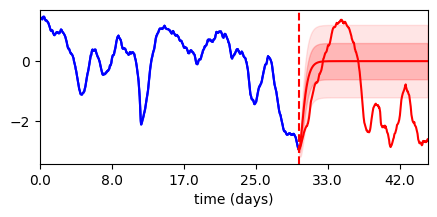

In [ ]:
fig, ax = plt.subplots(figsize=(5, 2),)

# Pick a location to plot predictions
i = 5
print(f'latitude {x[i, 0]}, longitude {x[i, 1]}')

# Plot the training data and predictions
ax.plot(t_train, y_train_normalised[:, i], 'blue', label='training data')
ax.plot(t_train, gp_mean_train[:, i], 'blue', label='predicted training mean')
plot_std(t_train, gp_mean_train[:, i], gp_std_train[:, i], ax=ax, alpha=0.2, color='blue')

# Plot the test data and predictions
ax.plot(t_test, y_test_normalised[:, i], 'red', label='test data')
ax.plot(t_test, gp_mean_test[:, i], 'red')
plot_std(t_test, gp_mean_test[:, i], gp_std_test[:, i], ax=ax, alpha=0.2, color='red')
plot_std(t_test, gp_mean_test[:, i], 2*gp_std_test[:, i], ax=ax, alpha=0.1, color='red')

ax.axvline(t_train[-1], color='red', linestyle='--')
ax.set_xticks(ax.get_xticks(), np.around(ax.get_xticks()/24));
ax.margins(x=0)
ax.set_xlabel('time (days)');